In [1]:
## import packages
import os
import sys
import xarray as xr
from matplotlib.patches import Ellipse # draw ellipse on figures
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
import mpu # compute storm centorid movement
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs


In [2]:
# import storm tracking functions
# import storm dataset
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
# import the functions of storm_direction.py file
from functions.storm_direction import mean_direction, mean_velocity, mean_direction_weighted

In [3]:
# storm dataset file path
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/storm_events/storm_start_2012-05-26_end_2012-05-27_Buffer_1.5.nc'
# read storm dataset
ds = xr.open_dataset(f)


In [4]:
##Run of storm tracking for specif event
event_dict = {}
storm_tracking_event(ds, event_dict, morph_radius=2, high_threshold=0.5, var_name='RAINRATE')
continuos_storm(event_dict)
storm_tracking_features(event_dict)

The longest storm has a valid duration of 9 hours
The selected duration is longer than 0.1 of 48 hours
Selected storm starts from 2012-05-26T16:00:00.000000000 to 2012-05-27T00:00:00.000000000
Selected storm duration 9 hours


{'storm_pcrp': <xarray.Variable (time: 48, latitude: 117, longitude: 130)> Size: 3MB
 array([[[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        ...,
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]],
 
        [[0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.],
         ...,
         [0., 0., ..., 0., 0.],
         [0., 0., ..., 0., 0.]]], shape=(48, 117, 130), dtype=float32)
 Attributes:
     long_name:     precipitation rate
     units:         mm hr^-1
     grid_mapping:  spatial_ref,
 'identification_array': array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0.

In [5]:
# plot average storm intesity within array
ds_mean = ds['RAINRATE'].mean(dim='latitude').mean(dim='longitude')


In [9]:
mean_direction_weighted(event_dict)

TypeError: mean_direction_weighted() missing 1 required positional argument: 'y'

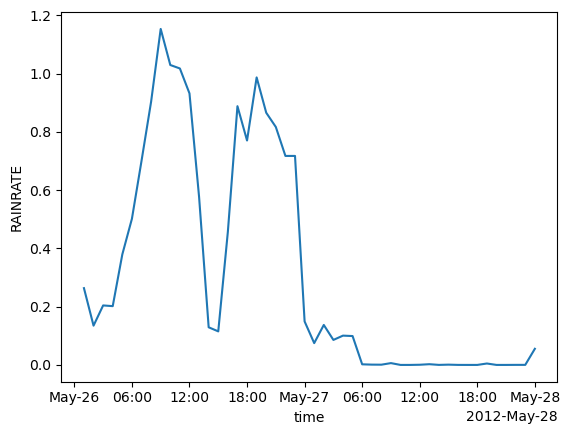

In [6]:
ds.RAINRATE.mean(dim='latitude').mean(dim='longitude').plot()

In [15]:
import imageio

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_63478/191403165.py:62: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_63478/191403165.py:62: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_63478/191403165.py:62: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_63478/191403165.py:62: UserWarning: Legend does not support handles for GeoQuadMesh instances.


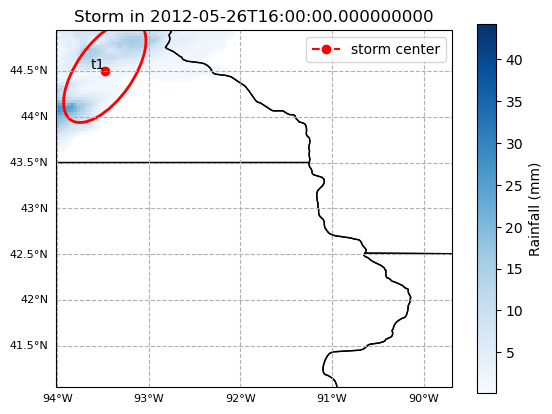

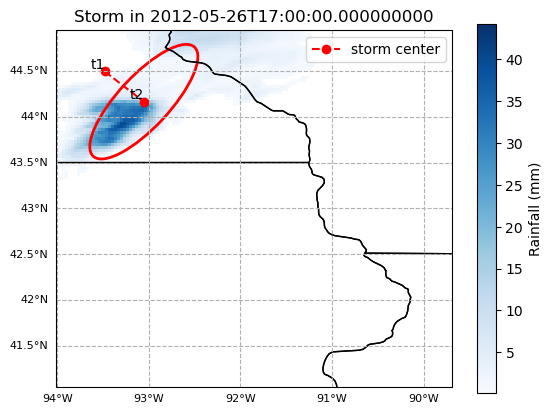

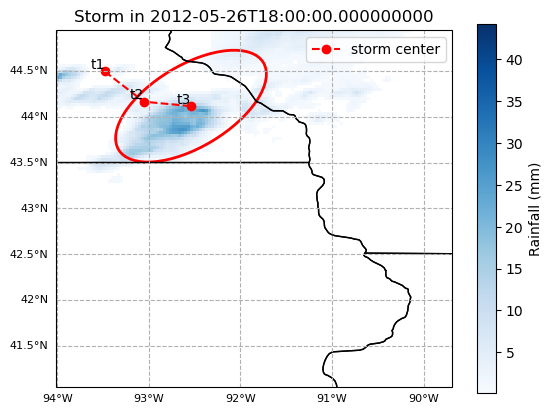

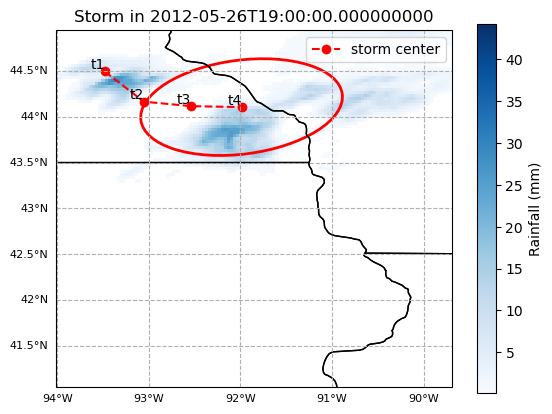

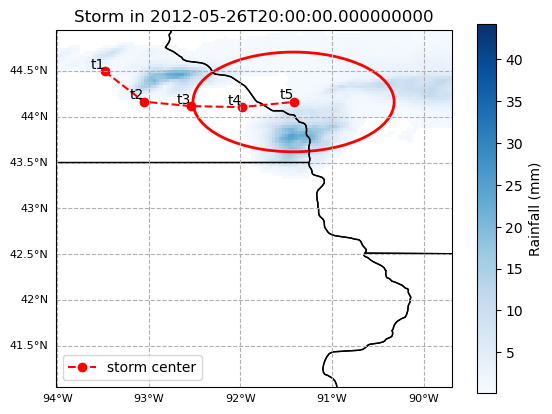

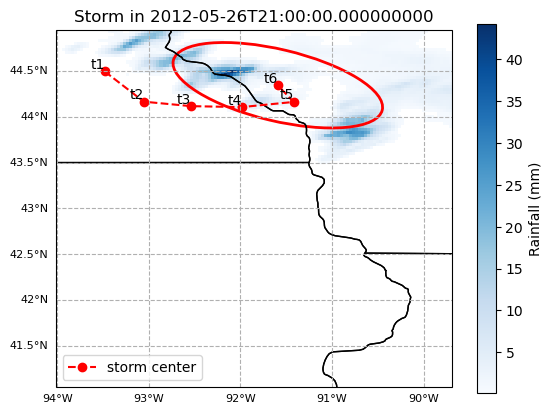

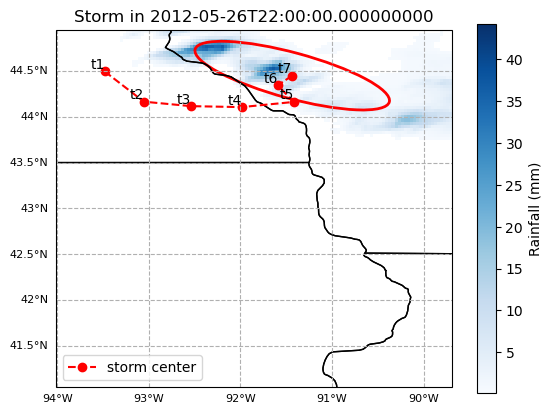

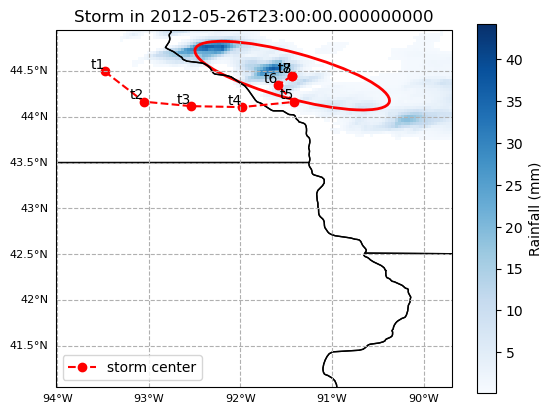

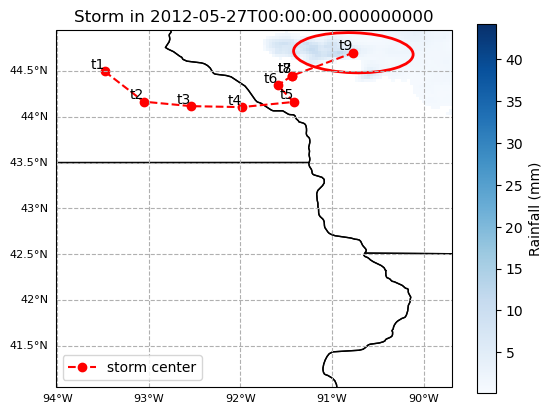

In [7]:

start_time_index = 0
end_time_index = 9
t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0]+1)] # time list for plotting
cb_max = event_dict['selected_storm'].max()
cb_min = 0.1

# plot storm event
for time_index in range(start_time_index,end_time_index):
  
    # get current precipitation array
    curr_prcp_array = event_dict['selected_storm'][time_index]
    
    # Create a plot
    
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the projected precipitation data
    rain = plt.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], np.ma.masked_where(curr_prcp_array < 0.5, curr_prcp_array),
                   cmap='Blues', vmax=cb_max, vmin=cb_min, label='Rainfall (mm/h)')
    plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical')
    
    ### Plot the storm centroid
    
    plt.plot(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
             event_dict['storm_lat_cent'][start_time_index:time_index+1], 'ro--', 
               label = 'storm center')
    for lon, lat, label in zip(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
                           event_dict['storm_lat_cent'][start_time_index:time_index+1], 
                           t_list[start_time_index:time_index+1]):
        plt.text(lon, lat, label, fontsize=10, ha='right', va='bottom')
    # plt.scatter(storm_lon_cent, storm_lat_cent)
    # scatter = ax.scatter(x_coords, y_coords, c=precipitation_data, cmap='viridis')
    # plt.colorbar(scatter, ax=ax, label='Precipitation')
    #basin_transposed.plot(ax=ax,  edgecolor='green', facecolor='none', label='Basin')
    
    # Plot the fitted ellipse
    ellipse_artist = Ellipse(
        xy=(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index]),
        width=event_dict['storm_record']['matplotlib_width(m)'][time_index]/111000, # the length of horizontal axis
        height=event_dict['storm_record']['matplotlib_height(m)'][time_index]/111000, # the length of vertical axis
        angle=event_dict['storm_record']['ellipse_angle (degree)'][time_index],
        edgecolor='red',
        fill=False,
        linewidth=2,
    )
    ax.add_artist(ellipse_artist)
    # Add U.S. state boundaries
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    # Add grid with labeled coordinates
    gl1 = ax.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    font_size = 8  # Set the desired font size
    gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
    gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

    # Set the axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = event_dict['selected_storm_time_steps'].values[time_index]
    ax.set_title(f'Storm in {title}')
    plt.legend()
    # Show the plot
    # Save the frame
    

 
    




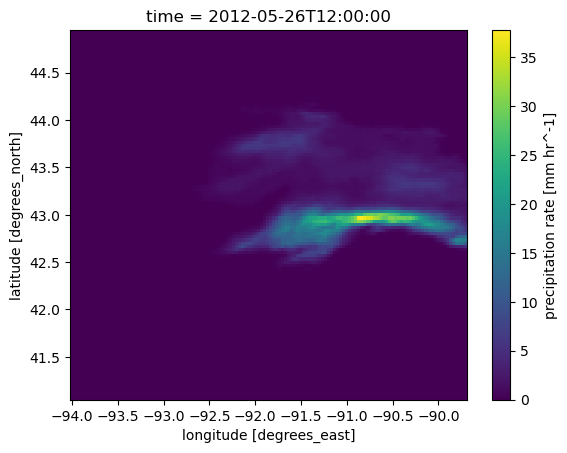

In [40]:
ds.sel(time='2012-05-26T12:00:00').RAINRATE.plot()

In [43]:
# storm direction 
x = event_dict['storm_prj_lon_cent_list'][start_time_index:end_time_index]
y = event_dict['storm_prj_lat_cent_list'][start_time_index:end_time_index]
v = mean_velocity(x, y)
d,vd = mean_direction(x, y)
wd, wv = mean_direction_weighted(x, y)

In [44]:
wd

np.float64(17.42282210609441)